# 4. Symmetry Before Dot Product

This chapter is intentionally before dot product.

The goal is not to memorize:

$$
u \cdot v = 0
$$

The goal is to understand what direction symmetry is trying to say before formulas compress it.



In [24]:
!pip install --upgrade pip
!pip install numpy matplotlib


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def setup_axis(ax, limit=3):
    ax.axhline(0, color="0.65", linewidth=1)
    ax.axvline(0, color="0.65", linewidth=1)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="0.88")

def draw_vector(ax, vector, label, color):
    x, y = vector
    ax.arrow(0, 0, x, y, head_width=0.12, length_includes_head=True, color=color, linewidth=2)
    ax.text(x * 1.08, y * 1.08, label, color=color, fontsize=11, weight="bold")

def draw_segment(ax, a, b, color="0.45", linestyle=":"):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    ax.plot([a[0], b[0]], [a[1], b[1]], color=color, linewidth=1.5, linestyle=linestyle)

def angle_deg(vector):
    vector = np.array(vector, dtype=float)
    return np.degrees(np.arctan2(vector[1], vector[0]))

def draw_angle(ax, start_deg, end_deg, radius, label, color, text_radius=None):
    arc = Arc((0, 0), 2 * radius, 2 * radius, angle=0, theta1=start_deg, theta2=end_deg, color=color, linewidth=2)
    ax.add_patch(arc)
    mid = np.radians((start_deg + end_deg) / 2)
    text_radius = text_radius or radius * 1.18
    ax.text(text_radius * np.cos(mid), text_radius * np.sin(mid), label, color=color, fontsize=10, weight="bold", ha="center", va="center")

def draw_vectors(title, vectors, limit=3):
    fig, ax = plt.subplots(figsize=(5, 5))
    setup_axis(ax, limit=limit)
    for vector, label, color in vectors:
        draw_vector(ax, np.array(vector, dtype=float), label, color)
    ax.set_title(title)
    plt.show()


## The Primitive Picture

A vector has two ideas mixed together:

- **direction**: where it points.
- **magnitude**: how long it is.

For now, we mostly ignore magnitude.

Think of all nonzero movements as simple direction choices.

In 1D, there are only two directions:

```text
left      right
<---- 0 ---->
```

In 2D, there are infinitely many directions around the origin:

```text
        up
        ^
        |
left <--0--> right
        |
        v
       down
```

In 3D, directions live around the origin in all spatial ways, not just on a flat circle.

The origin is the anchor of direction thinking.

A vector says:

> from the origin, move this way.



## Direction Without Magnitude

If we ignore magnitude, then these two vectors have the same direction:

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\quad
\text{and}
\quad
\begin{bmatrix}
2 \\
4
\end{bmatrix}
$$

because:

$$
\begin{bmatrix}
2 \\
4
\end{bmatrix}
=
2
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

One is just a longer version of the other.

Direction-only thinking treats them as living on the same ray.



## Opposite Direction

The opposite of a vector is made by flipping every component.

If:

$$
u =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

then:

$$
-u =
\begin{bmatrix}
-x \\
-y
\end{bmatrix}
$$

This is a $180^\circ$ turn.

Example:

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
-1 \\
-2
\end{bmatrix}
$$

Opposite does not mean perpendicular.

Opposite means:

> same line, reverse direction.



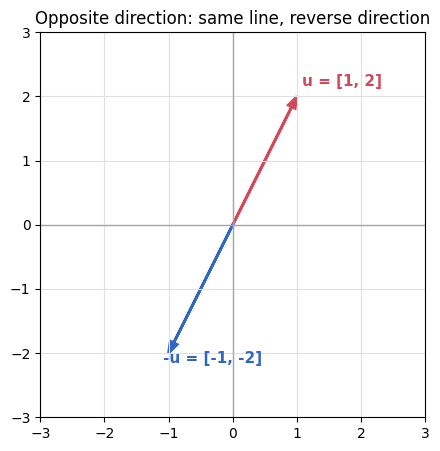

In [26]:
draw_vectors(
    "Opposite direction: same line, reverse direction",
    [
        ([1, 2], "u = [1, 2]", "#d1495b"),
        ([-1, -2], "-u = [-1, -2]", "#3066be"),
    ],
    limit=3,
)

## 1D Symmetry

In 1D, a vector has only one component:

$$
[x]
$$

There are only two direction signs:

$$
[+1]
\quad
\text{and}
\quad
[-1]
$$

They are opposites.

There is no perpendicular direction inside 1D.

Why?

Because there is no second independent way to move.

In 1D:

```text
rank / mobility = line only
```

No sideways exists.



## 2D Sign Symmetry Toy

Now look at equal-magnitude diagonal directions.

Use only signs first:

$$
[+,+]
$$

The four sign patterns are:

$$
[+,+]
$$

$$
[-,-]
$$

$$
[+,-]
$$

$$
[-,+]
$$

For the vector $[1,1]$:

- $[1,1]$ is same direction.
- $[-1,-1]$ is opposite direction.
- $[1,-1]$ is perpendicular.
- $[-1,1]$ is also perpendicular.

Visually:

```text
        [-1,1]
           ^
           |
[-1,-1] <--0--> [1,1]
           |
           v
        [1,-1]
```

This symmetry is beautiful, but dangerous.

It works cleanly here because the magnitudes match:

$$
|x| = |y|
$$

The vector sits on a $45^\circ$ diagonal.



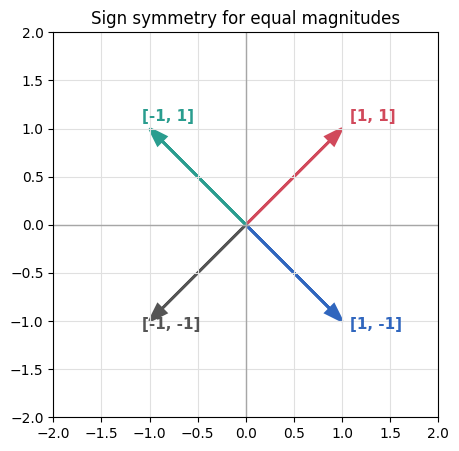

In [27]:
draw_vectors(
    "Sign symmetry for equal magnitudes",
    [
        ([1, 1], "[1, 1]", "#d1495b"),
        ([-1, -1], "[-1, -1]", "#555555"),
        ([1, -1], "[1, -1]", "#3066be"),
        ([-1, 1], "[-1, 1]", "#2a9d8f"),
    ],
    limit=2,
)

## Why Sign Symmetry Is Not Enough

For:

$$
u =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

just flipping one sign gives:

$$
\begin{bmatrix}
1 \\
-2
\end{bmatrix}
$$

This is not generally perpendicular.

It is a reflection across the $x$-axis.

Reflection is not the same as a quarter-turn.

This is the trap:

> sign flips can describe symmetry, but they do not fully describe perpendicularity once magnitudes differ.

Magnitude starts changing the angle.



## Swap Alone Is Reflection

Take:

$$
u =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

Swapping coordinates gives:

$$
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

This is a reflection across the line $y=x$.

The line $y=x$ acts like a mirror.

Points sitting exactly on the mirror do not move:

$$
[1,1] \rightarrow [1,1]
$$

because swapping equal coordinates changes nothing.

But a point away from the mirror crosses to the symmetric position on the other side:

$$
[1,2] \rightarrow [2,1]
$$

The distance to the mirror is preserved, like a real reflection.

So:

$$
[x,y] \rightarrow [y,x]
$$

means mirror across the diagonal.

It does not mean perpendicular.



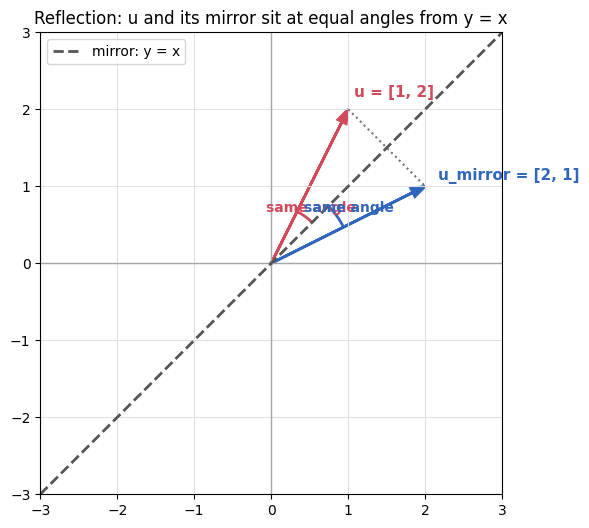

In [28]:
u = np.array([1, 2], dtype=float)
reflected = np.array([2, 1], dtype=float)
mirror = np.linspace(-3, 3, 100)
u_angle = angle_deg(u)
ref_angle = angle_deg(reflected)
mirror_angle = 45

fig, ax = plt.subplots(figsize=(6, 6))
setup_axis(ax, limit=3)
ax.plot(mirror, mirror, color="#555555", linestyle="--", linewidth=2, label="mirror: y = x")
draw_vector(ax, u, "u = [1, 2]", "#d1495b")
draw_vector(ax, reflected, "u_mirror = [2, 1]", "#3066be")
draw_segment(ax, u, reflected)
draw_angle(ax, mirror_angle, u_angle, 0.75, "same angle", "#d1495b")
draw_angle(ax, ref_angle, mirror_angle, 1.05, "same angle", "#3066be")
ax.set_title("Reflection: u and its mirror sit at equal angles from y = x")
ax.legend()
plt.show()

## Mirror Plus Flip

The perpendicular operation can be seen as two simpler moves:

1. mirror across $y=x$ by swapping coordinates.
2. flip one axis.

Start with:

$$
[x,y]
$$

Mirror across $y=x$:

$$
[x,y] \rightarrow [y,x]
$$

Now flip the new $y$ coordinate:

$$
[y,x] \rightarrow [y,-x]
$$

This gives the clockwise perpendicular direction.

Or flip the new $x$ coordinate:

$$
[y,x] \rightarrow [-y,x]
$$

This gives the counterclockwise perpendicular direction.

So perpendicularity in 2D can be remembered as:

> mirror, then flip one axis.

This is the same as:

> swap components, then flip exactly one sign.

For:

$$
u =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

mirror first:

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

then flip one axis:

$$
\begin{bmatrix}
2 \\
1
\end{bmatrix}
\rightarrow
\begin{bmatrix}
2 \\
-1
\end{bmatrix}
$$

or:

$$
\begin{bmatrix}
2 \\
1
\end{bmatrix}
\rightarrow
\begin{bmatrix}
-2 \\
1
\end{bmatrix}
$$

Those are the two perpendicular directions.

The mirror alone gives symmetry.

The mirror plus an axis flip gives the quarter-turn.




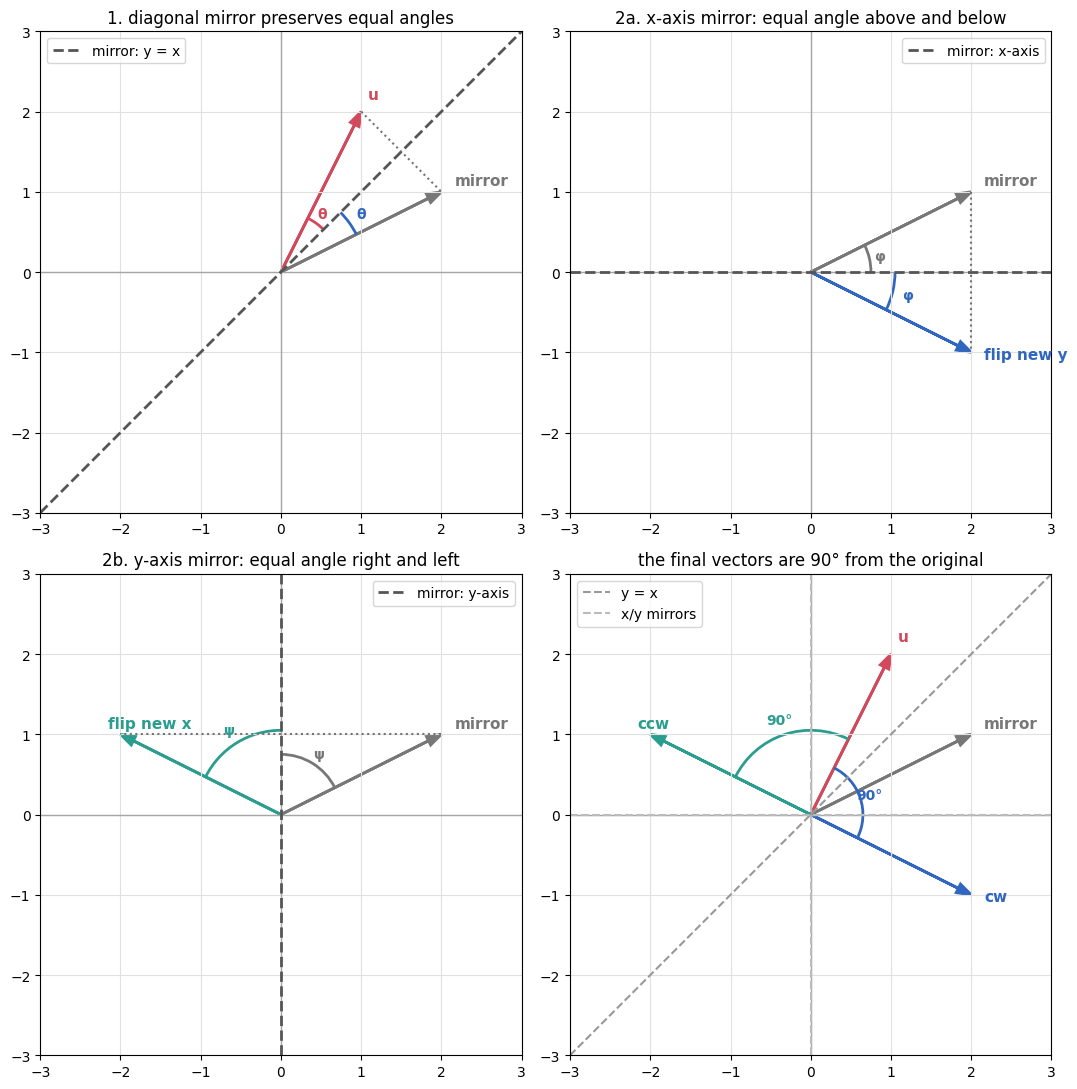

In [29]:
u = np.array([1, 2], dtype=float)
mirror_reflection = np.array([2, 1], dtype=float)
clockwise = np.array([2, -1], dtype=float)
counterclockwise = np.array([-2, 1], dtype=float)
mirror = np.linspace(-3, 3, 100)

fig, axs = plt.subplots(2, 2, figsize=(11, 11))
axs = axs.ravel()

setup_axis(axs[0], limit=3)
axs[0].plot(mirror, mirror, color="#555555", linestyle="--", linewidth=2, label="mirror: y = x")
draw_vector(axs[0], u, "u", "#d1495b")
draw_vector(axs[0], mirror_reflection, "mirror", "#777777")
draw_segment(axs[0], u, mirror_reflection)
draw_angle(axs[0], 45, angle_deg(u), 0.75, "θ", "#d1495b")
draw_angle(axs[0], angle_deg(mirror_reflection), 45, 1.05, "θ", "#3066be")
axs[0].set_title("1. diagonal mirror preserves equal angles")
axs[0].legend()

setup_axis(axs[1], limit=3)
axs[1].axhline(0, color="#555555", linestyle="--", linewidth=2, label="mirror: x-axis")
draw_vector(axs[1], mirror_reflection, "mirror", "#777777")
draw_vector(axs[1], clockwise, "flip new y", "#3066be")
draw_segment(axs[1], mirror_reflection, clockwise)
draw_angle(axs[1], 0, angle_deg(mirror_reflection), 0.75, "φ", "#777777")
draw_angle(axs[1], angle_deg(clockwise), 0, 1.05, "φ", "#3066be")
axs[1].set_title("2a. x-axis mirror: equal angle above and below")
axs[1].legend()

setup_axis(axs[2], limit=3)
axs[2].axvline(0, color="#555555", linestyle="--", linewidth=2, label="mirror: y-axis")
draw_vector(axs[2], mirror_reflection, "mirror", "#777777")
draw_vector(axs[2], counterclockwise, "flip new x", "#2a9d8f")
draw_segment(axs[2], mirror_reflection, counterclockwise)
draw_angle(axs[2], angle_deg(mirror_reflection), 90, 0.75, "ψ", "#777777")
draw_angle(axs[2], 90, angle_deg(counterclockwise), 1.05, "ψ", "#2a9d8f")
axs[2].set_title("2b. y-axis mirror: equal angle right and left")
axs[2].legend()

setup_axis(axs[3], limit=3)
axs[3].plot(mirror, mirror, color="#999999", linestyle="--", linewidth=1.5, label="y = x")
axs[3].axhline(0, color="#bbbbbb", linestyle="--", linewidth=1.5, label="x/y mirrors")
axs[3].axvline(0, color="#bbbbbb", linestyle="--", linewidth=1.5)
draw_vector(axs[3], u, "u", "#d1495b")
draw_vector(axs[3], mirror_reflection, "mirror", "#777777")
draw_vector(axs[3], clockwise, "cw", "#3066be")
draw_vector(axs[3], counterclockwise, "ccw", "#2a9d8f")
draw_angle(axs[3], angle_deg(clockwise), angle_deg(u), 0.65, "90°", "#3066be")
draw_angle(axs[3], angle_deg(u), angle_deg(counterclockwise), 1.05, "90°", "#2a9d8f")
axs[3].set_title("the final vectors are 90° from the original")
axs[3].legend()

plt.tight_layout()
plt.show()

## Axis Flips Are Also Mirrors

Flipping only one coordinate is also a reflection.

If we flip the $x$ coordinate:

$$
[x,y] \rightarrow [-x,y]
$$

that is a mirror across the $y$-axis.

The $y$-axis stays fixed, and the point folds to the other side horizontally.

If we flip the $y$ coordinate:

$$
[x,y] \rightarrow [x,-y]
$$

that is a mirror across the $x$-axis.

The $x$-axis stays fixed, and the point folds to the other side vertically.

So the perpendicular construction can be read as two reflections:

1. reflect across the diagonal mirror $y=x$.
2. reflect across one coordinate-axis mirror.

Start with:

$$
u = [x,y]
$$

After diagonal reflection, call the reflected vector:

$$
u_{mirror} = [y,x]
$$

Here the old $y$ now sits in the new $x$ coordinate, and the old $x$ now sits in the new $y$ coordinate.

Then flip the new $y$ coordinate:

$$
[y,x] \rightarrow [y,-x]
$$

This is reflection across the $x$-axis.

Or flip the new $x$ coordinate:

$$
[y,x] \rightarrow [-y,x]
$$

This is reflection across the $y$-axis.

So the two perpendiculars are:

$$
u_{cw} = [y,-x]
$$

and:

$$
u_{ccw} = [-y,x]
$$

The two-step geometry is:

```text
original vector
  -> mirror across y = x
  -> mirror across x-axis or y-axis
  -> perpendicular vector
```

This is why it feels like folding paper.

The first fold swaps the coordinate roles.

The second fold opposes one of the new coordinate directions.

Together they produce a $90^\circ$ turn.



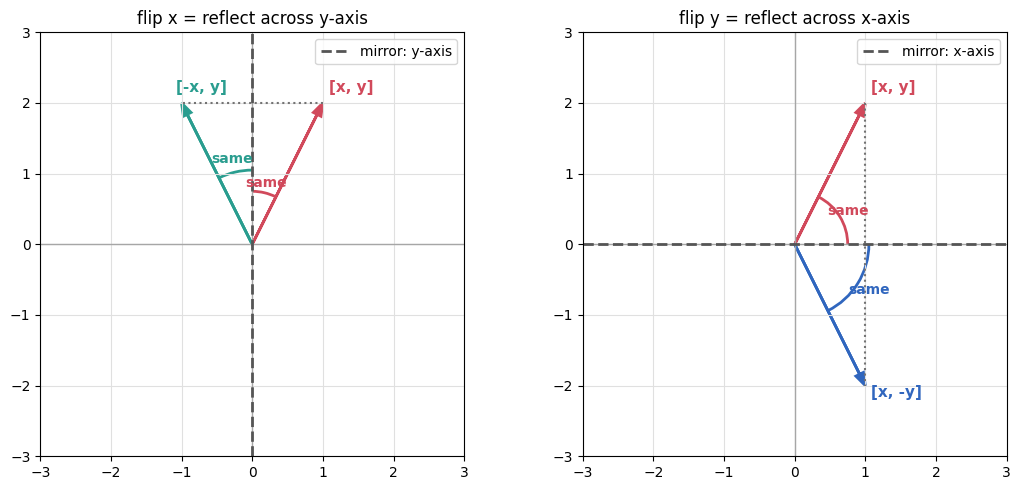

In [30]:
u = np.array([1, 2], dtype=float)
x_flip = np.array([-1, 2], dtype=float)
y_flip = np.array([1, -2], dtype=float)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
setup_axis(axs[0], limit=3)
axs[0].axvline(0, color="#555555", linestyle="--", linewidth=2, label="mirror: y-axis")
draw_vector(axs[0], u, "[x, y]", "#d1495b")
draw_vector(axs[0], x_flip, "[-x, y]", "#2a9d8f")
draw_segment(axs[0], u, x_flip)
draw_angle(axs[0], angle_deg(u), 90, 0.75, "same", "#d1495b")
draw_angle(axs[0], 90, angle_deg(x_flip), 1.05, "same", "#2a9d8f")
axs[0].set_title("flip x = reflect across y-axis")
axs[0].legend()

setup_axis(axs[1], limit=3)
axs[1].axhline(0, color="#555555", linestyle="--", linewidth=2, label="mirror: x-axis")
draw_vector(axs[1], u, "[x, y]", "#d1495b")
draw_vector(axs[1], y_flip, "[x, -y]", "#3066be")
draw_segment(axs[1], u, y_flip)
draw_angle(axs[1], 0, angle_deg(u), 0.75, "same", "#d1495b")
draw_angle(axs[1], angle_deg(y_flip), 0, 1.05, "same", "#3066be")
axs[1].set_title("flip y = reflect across x-axis")
axs[1].legend()

plt.tight_layout()
plt.show()

## Quarter-Turn In 2D

A perpendicular direction in 2D is a quarter-turn.

A counterclockwise quarter-turn sends:

```text
right -> up
up    -> left
```

So if:

$$
u =
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

then counterclockwise perpendicular is:

$$
\begin{bmatrix}
-y \\
x
\end{bmatrix}
$$

Clockwise quarter-turn sends:

```text
right -> down
up    -> right
```

So clockwise perpendicular is:

$$
\begin{bmatrix}
y \\
-x
\end{bmatrix}
$$

This is why the operation is:

> swap components, then flip exactly one sign.

Example:

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
-2 \\
1
\end{bmatrix}
$$

or:

$$
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
2 \\
-1
\end{bmatrix}
$$

Both are perpendicular directions.

They are opposites of each other.



In [ ]:
draw_vectors(
    "Quarter-turns: swap components and flip one sign",
    [
        ([1, 2], "u = [1, 2]", "#d1495b"),
        ([-2, 1], "ccw = [-2, 1]", "#2a9d8f"),
        ([2, -1], "cw = [2, -1]", "#3066be"),
    ],
    limit=3,
)

## The 2D Perpendicular Line

In 2D, one nonzero vector has one perpendicular line.

If $u$ points this way:

```text
      u
     /
    /
---0---------
```

then all perpendicular vectors live on the line crossing it at $90^\circ$:

```text
      | perpendicular line
      |
      |   u
      |  /
------0-/------
      |
      |
```

There are two unit directions on that perpendicular line, but infinitely many magnitudes.

So the perpendicular family is:

$$
\{s[-y,x] \mid s \in \mathbb{R}\}
$$

for:

$$
u = [x,y]
$$

Plain:

> in 2D, perpendicularity leaves one degree of freedom: how far along the perpendicular line.



In [ ]:
u = np.array([1, 2], dtype=float)
p = np.array([-u[1], u[0]], dtype=float)
line = np.linspace(-2, 2, 100)
points = np.outer(line, p)

fig, ax = plt.subplots(figsize=(5, 5))
setup_axis(ax, limit=3)
ax.plot(points[:, 0], points[:, 1], color="#2a9d8f", linewidth=2, label="perpendicular line")
draw_vector(ax, u, "u", "#d1495b")
draw_vector(ax, p, "[-y, x]", "#2a9d8f")
draw_vector(ax, -p, "[y, -x]", "#3066be")
ax.set_title("All scalar multiples of [-y, x] are perpendicular to u")
ax.legend()
plt.show()

## 3D Changes The Picture

In 3D, a single vector does not have one perpendicular line.

It has a whole perpendicular plane.

Example:

$$
u =
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix}
$$

A vector:

$$
v =
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
$$

is perpendicular to $u$ when its $x$ and $z$ contributions cancel.

The $y$ direction is free because $u$ has no $y$ component.

So all vectors like this are perpendicular to $u$:

$$
\begin{bmatrix}
x \\
y \\
-x
\end{bmatrix}
$$

Examples:

$$
\begin{bmatrix}
1 \\
0 \\
-1
\end{bmatrix}
$$

$$
\begin{bmatrix}
1 \\
100 \\
-1
\end{bmatrix}
$$

$$
\begin{bmatrix}
-3 \\
7 \\
3
\end{bmatrix}
$$

All of them live in the perpendicular plane.

This is why sign tables stop being enough.

In 3D, perpendicularity is no longer just two options.

It becomes a whole space of options.



## Orthogonal Complement Preview

The full set of vectors perpendicular to a vector $u$ is called its orthogonal complement.

Written:

$$
u^\perp
$$

Read:

> all directions with no net agreement with $u$.

In 1D:

$$
u^\perp
$$

has dimension $0$.

In 2D:

$$
u^\perp
$$

is a line.

In 3D:

$$
u^\perp
$$

is a plane.

In $n$ dimensions, the perpendicular space to one nonzero vector has dimension:

$$
n - 1
$$



## What We Learned Before Dot Product

Before formulas, the symmetry picture is:

- same direction: scale by a positive number.
- opposite direction: scale by a negative number, especially $-1$ for exact reversal.
- reflection: flip signs or swap coordinates depending on the mirror.
- perpendicular in 2D: quarter-turn, swap components and flip one sign.
- perpendicular in 3D: a whole plane of possible directions.

So dot product will not be magic.

It will become the accounting system for this question:

> how much directional agreement remains after all coordinates contribute?
